In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print("Libraries loaded!")

Libraries loaded!


In [2]:
import pandas as pd

print(pd.__version__)

2.3.3


In [3]:
data = {
    'name':   ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'age':    [25, 30, 35, 28, 22],
    'city':   ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai'],
    'salary': [50000, 70000, 65000, 80000, 45000]
}

df = pd.DataFrame(data)
print(df)

      name  age     city  salary
0    Alice   25    Delhi   50000
1      Bob   30   Mumbai   70000
2  Charlie   35    Delhi   65000
3    Diana   28  Chennai   80000
4      Eve   22   Mumbai   45000


In [4]:
df.shape

(5, 4)

In [5]:
df.dtypes

name      object
age        int64
city      object
salary     int64
dtype: object

In [6]:
df.head(3)

,name,age,city,salary
0,Alice,25,Delhi,50000
1,Bob,30,Mumbai,70000
2,Charlie,35,Delhi,65000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    5 non-null      object
 1   age     5 non-null      int64 
 2   city    5 non-null      object
 3   salary  5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes


In [8]:
df[df['age']>25]

,name,age,city,salary
1,Bob,30,Mumbai,70000
2,Charlie,35,Delhi,65000
3,Diana,28,Chennai,80000


In [9]:
df[df['city']=='Delhi']

,name,age,city,salary
0,Alice,25,Delhi,50000
2,Charlie,35,Delhi,65000


In [10]:
df[(df['age']>25) & (df['city']=='Mumbai')]

,name,age,city,salary
1,Bob,30,Mumbai,70000


In [11]:
df.groupby('city')['salary'].mean()

city
Chennai    80000.0
Delhi      57500.0
Mumbai     57500.0
Name: salary, dtype: float64

In [12]:
df.groupby('city')['salary'].agg(['mean', 'max', 'count'])

,mean,max,count
city,,,
Chennai,80000.0,80000,1
Delhi,57500.0,65000,2
Mumbai,57500.0,70000,2


In [13]:
df['senior'] = df['age']>28
df.groupby('senior')['salary'].mean()

senior
False    58333.333333
True     67500.000000
Name: salary, dtype: float64

In [14]:
import numpy as np

data2 = {
    'name':   ['Alice', 'Bob', 'Charlie', 'Diana'],
    'salary': [50000, None, 65000, None],
    'city':   ['Delhi', 'Mumbai', None, 'Chennai']
}

df2 = pd.DataFrame(data2)
print(df2)

      name   salary     city
0    Alice  50000.0    Delhi
1      Bob      NaN   Mumbai
2  Charlie  65000.0     None
3    Diana      NaN  Chennai


In [15]:
df2.isnull()

,name,salary,city
0,False,False,False
1,False,True,False
2,False,False,True
3,False,True,False


In [16]:
df2.isnull().sum()

name      0
salary    2
city      1
dtype: int64

In [17]:
df2['salary'].fillna(df2['salary'].mean())

0    50000.0
1    57500.0
2    65000.0
3    57500.0
Name: salary, dtype: float64

In [18]:
df2['city'].fillna('unknown')

0      Delhi
1     Mumbai
2    unknown
3    Chennai
Name: city, dtype: object

In [19]:
df2.dropna()

,name,salary,city
0,Alice,50000.0,Delhi


In [20]:
df2['salary'] = df2['salary'].fillna(df2['salary'].mean())
df2['city']   = df2['city'].fillna('Unknown')

print(df2)
print("\nMissing values remaining:")
print(df2.isnull().sum())

      name   salary     city
0    Alice  50000.0    Delhi
1      Bob  57500.0   Mumbai
2  Charlie  65000.0  Unknown
3    Diana  57500.0  Chennai

Missing values remaining:
name      0
salary    0
city      0
dtype: int64


In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    'order_id':  range(1, 201),
    'product':   np.random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard'], 200),
    'category':  None,
    'quantity':  np.random.randint(1, 6, 200),
    'price':     np.random.choice([15000, 25000, 8000, 12000, 2000], 200),
    'city':      np.random.choice(['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Pune'], 200),
    'month':     np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], 200),
}

df = pd.DataFrame(data)

category_map = {
    'Laptop': 'Electronics',
    'Phone': 'Electronics',
    'Tablet': 'Electronics',
    'Monitor': 'Accessories',
    'Keyboard': 'Accessories'
}
df['category'] = df['product'].map(category_map)

df.loc[np.random.choice(df.index, 10), 'city'] = np.nan
df.loc[np.random.choice(df.index, 8),  'quantity'] = np.nan

df['revenue'] = df['quantity'] * df['price']

df.to_csv('sales_data.csv', index=False)
print("CSV created! Shape:", df.shape)
print(df.head())

CSV created! Shape: (200, 8)
   order_id   product     category  quantity  price     city month  revenue
0         1   Monitor  Accessories       2.0   8000  Chennai   Mar  16000.0
1         2  Keyboard  Accessories       3.0   2000  Kolkata   Jun   6000.0
2         3    Tablet  Electronics       1.0  15000     Pune   Mar  15000.0
3         4  Keyboard  Accessories       1.0   2000  Kolkata   Apr   2000.0
4         5  Keyboard  Accessories       4.0  12000      NaN   May  48000.0


In [22]:
df = pd.read_csv('sales_data.csv')
print("Shape:",df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (200, 8)

Missing values:
order_id     0
product      0
category     0
quantity     8
price        0
city        10
month        0
revenue      8
dtype: int64

First 5 rows:


,order_id,product,category,quantity,price,city,month,revenue
0,1,Monitor,Accessories,2.0,8000,Chennai,Mar,16000.0
1,2,Keyboard,Accessories,3.0,2000,Kolkata,Jun,6000.0
2,3,Tablet,Electronics,1.0,15000,Pune,Mar,15000.0
3,4,Keyboard,Accessories,1.0,2000,Kolkata,Apr,2000.0
4,5,Keyboard,Accessories,4.0,12000,NaN,May,48000.0


In [23]:
df['city']     = df['city'].fillna('Unknown')
df['quantity'] = df['quantity'].fillna(df['quantity'].mean())
df['revenue']  = df['quantity'] * df['price']

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
order_id    0
product     0
category    0
quantity    0
price       0
city        0
month       0
revenue     0
dtype: int64


In [24]:
product_revenue = df.groupby('product')['revenue'].sum().sort_values(ascending=False)
print("Revenue by product:\n", product_revenue)

Revenue by product:
 product
Monitor     1.754000e+06
Laptop      1.482844e+06
Tablet      1.308604e+06
Phone       1.288208e+06
Keyboard    9.644167e+05
Name: revenue, dtype: float64


In [25]:
city_orders = df.groupby('city')['order_id'].count().sort_values(ascending=False)
print("Orders by city:\n", city_orders)

Orders by city:
 city
Pune       43
Mumbai     41
Delhi      39
Chennai    37
Kolkata    30
Unknown    10
Name: order_id, dtype: int64


In [26]:
month_revenue = df.groupby('month')['revenue'].sum().sort_values(ascending=False)
print("Revenue by month:\n", month_revenue)

Revenue by month:
 month
Jun    1.536000e+06
May    1.122823e+06
Jan    1.120208e+06
Feb    1.053208e+06
Apr    9.885156e+05
Mar    9.773177e+05
Name: revenue, dtype: float64


In [27]:
category_stats = df.groupby('category')['revenue'].agg(['sum', 'count', 'mean'])
category_stats.columns = ['total_revenue', 'orders', 'avg_order_value']
print(category_stats)

             total_revenue  orders  avg_order_value
category                                           
Accessories   2.718417e+06      85     31981.372549
Electronics   4.079656e+06     115     35475.271739


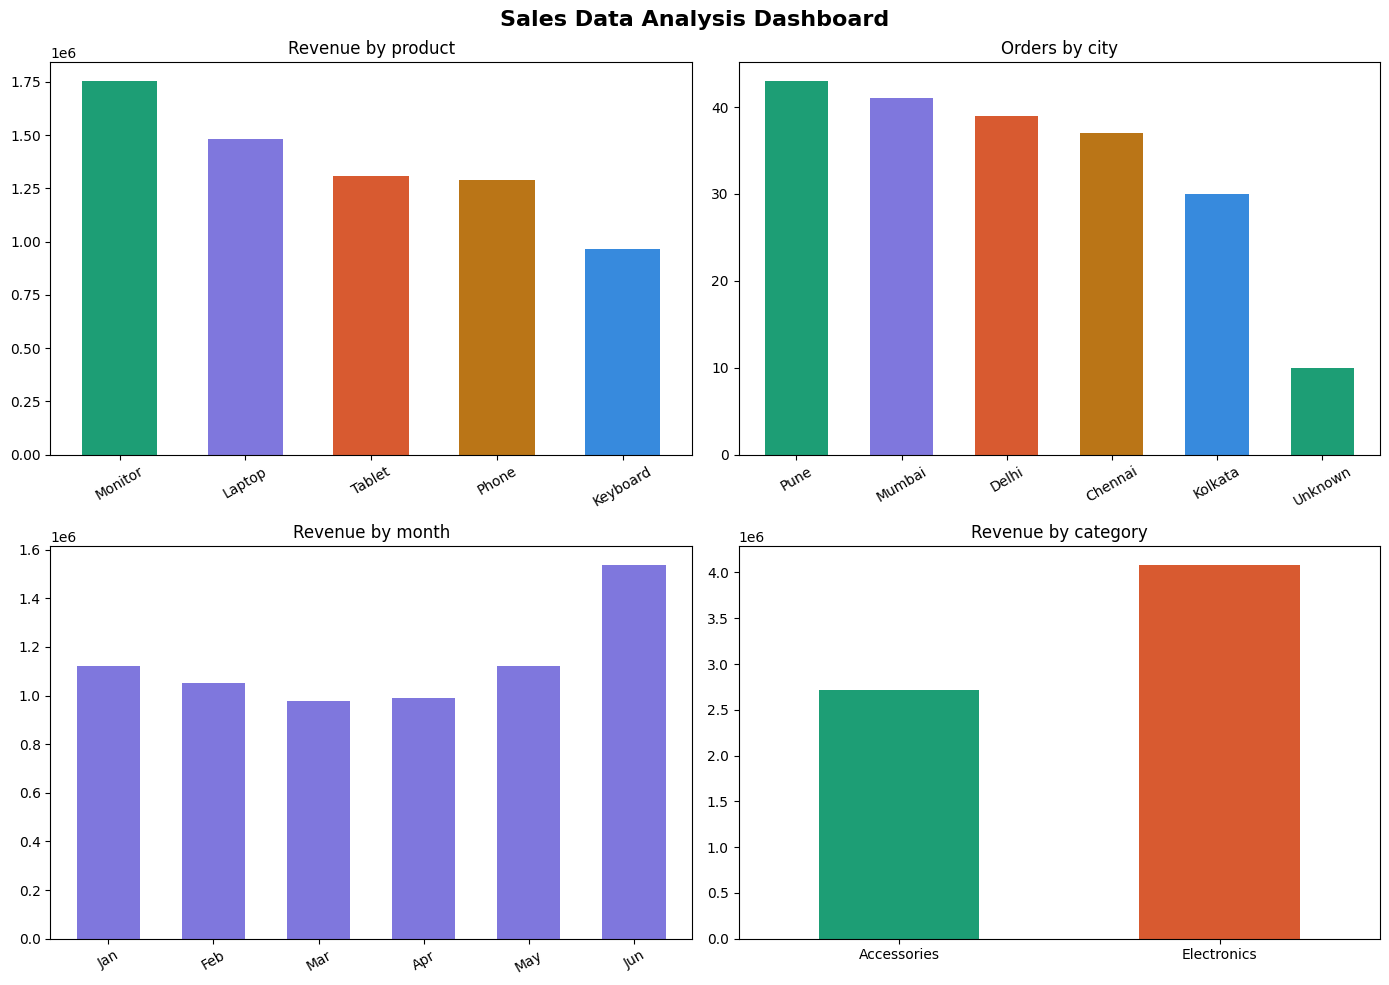

Dashboard saved to charts/sales_dashboard.png


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Data Analysis Dashboard', fontsize=16, fontweight='bold')

colors = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517', '#378ADD']

# Chart 1 — Revenue by product
product_revenue.plot(kind='bar', ax=axes[0,0], color=colors, width=0.6)
axes[0,0].set_title('Revenue by product')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2 — Orders by city
city_orders.plot(kind='bar', ax=axes[0,1], color=colors, width=0.6)
axes[0,1].set_title('Orders by city')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=30)

# Chart 3 — Revenue by month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
month_revenue.reindex(month_order).plot(kind='bar', ax=axes[1,0],
                                         color='#7F77DD', width=0.6)
axes[1,0].set_title('Revenue by month')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=30)

# Chart 4 — Category comparison
category_stats['total_revenue'].plot(kind='bar', ax=axes[1,1],
                                      color=['#1D9E75', '#D85A30'], width=0.5)
axes[1,1].set_title('Revenue by category')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('charts/sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard saved to charts/sales_dashboard.png")